# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [3]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [ ]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

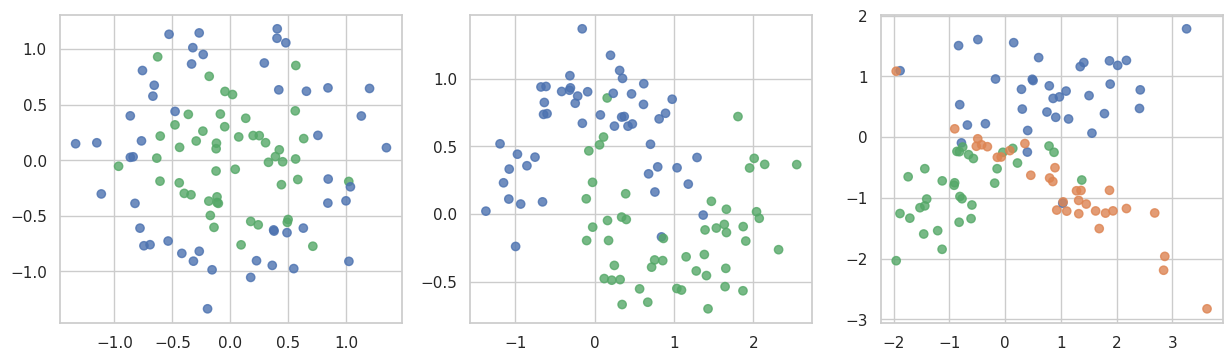

In [11]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [12]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

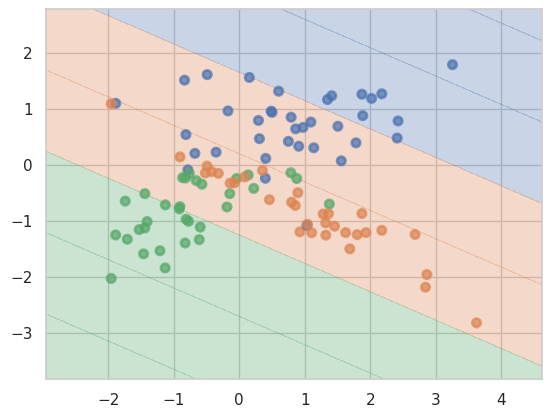

In [13]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

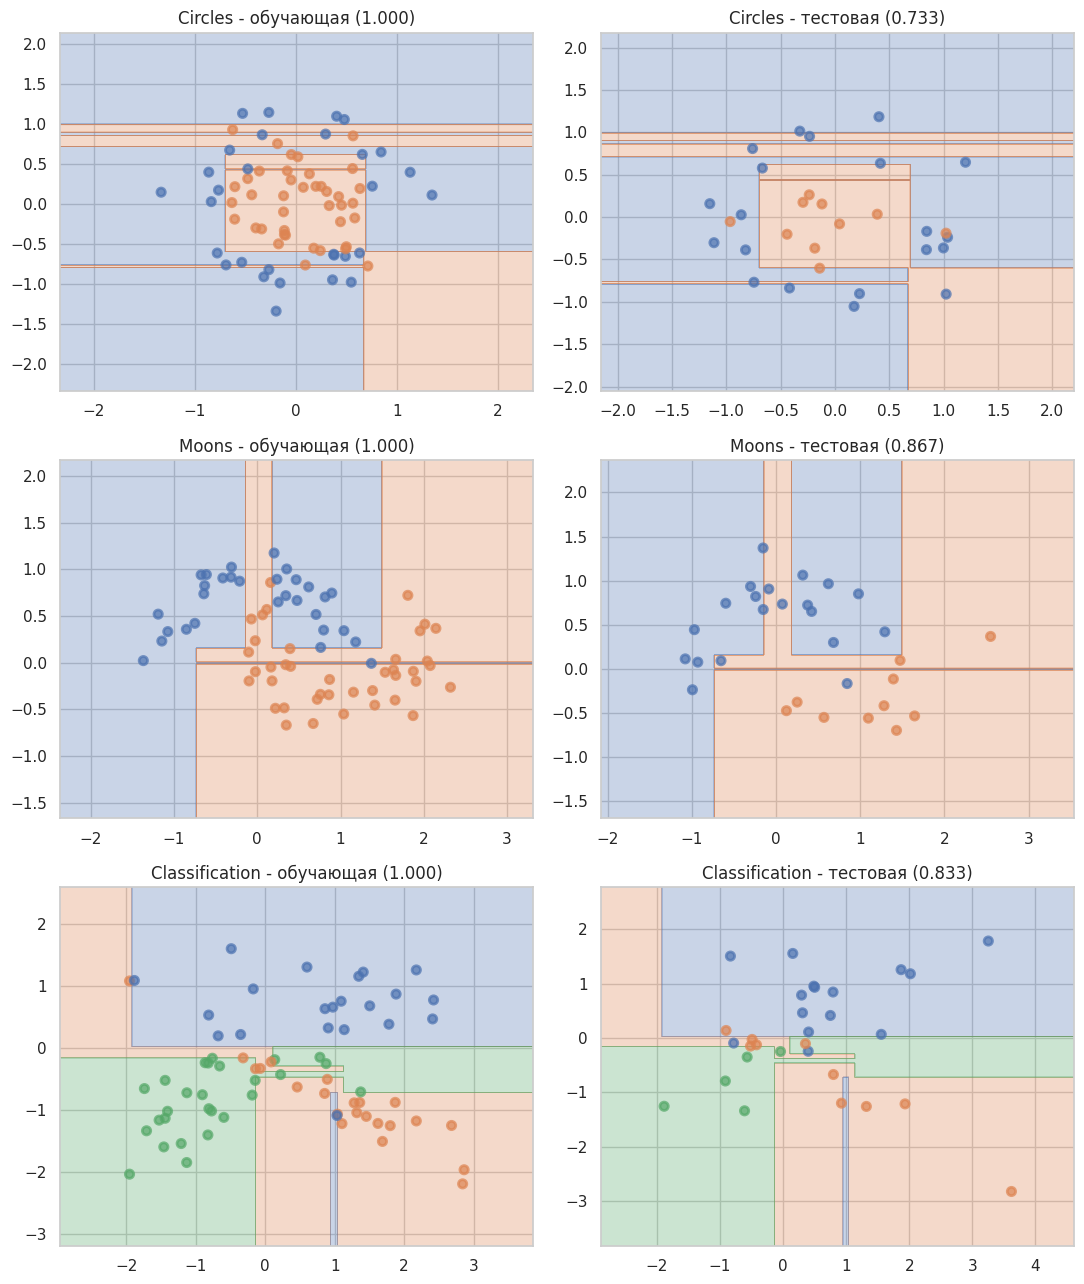


Результаты обучения:

Circles: train=1.000, test=0.733, разница=0.267 (сильное переобучение)
Moons: train=1.000, test=0.867, разница=0.133 (сильное переобучение)
Classification: train=1.000, test=0.833, разница=0.167 (сильное переобучение)


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=0.7,
                edgecolors=np.array(palette)[y], linewidths=2)

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, 
                       class_sep=0.8, random_state=3, n_redundant=0)
]

dataset_names = ['Circles', 'Moons', 'Classification']

fig, axes = plt.subplots(3, 2, figsize=(11, 13))
metrics_data = []

for idx, ((X, y), ds_name) in enumerate(zip(datasets, dataset_names)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    
    acc_train = accuracy_score(y_train, train_pred)
    acc_test = accuracy_score(y_test, test_pred)
    
    metrics_data.append({
        'name': ds_name,
        'train': acc_train,
        'test': acc_test,
        'gap': acc_train - acc_test
    })
    
    plt.subplot(3, 2, idx*2 + 1)
    plot_surface(clf, X_train, y_train)
    plt.title(f'{ds_name} - обучающая ({acc_train:.3f})')
    
    plt.subplot(3, 2, idx*2 + 2)
    plot_surface(clf, X_test, y_test)
    plt.title(f'{ds_name} - тестовая ({acc_test:.3f})')

plt.tight_layout()
plt.show()

print("\nРезультаты обучения:\n")
for m in metrics_data:
    overfit_level = "сильное" if m['gap'] > 0.1 else "умеренное" if m['gap'] > 0.05 else "слабое"
    print(f"{m['name']}: train={m['train']:.3f}, test={m['test']:.3f}, "
          f"разница={m['gap']:.3f} ({overfit_level} переобучение)")


__Ответ:__ все деревья переобучились((

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

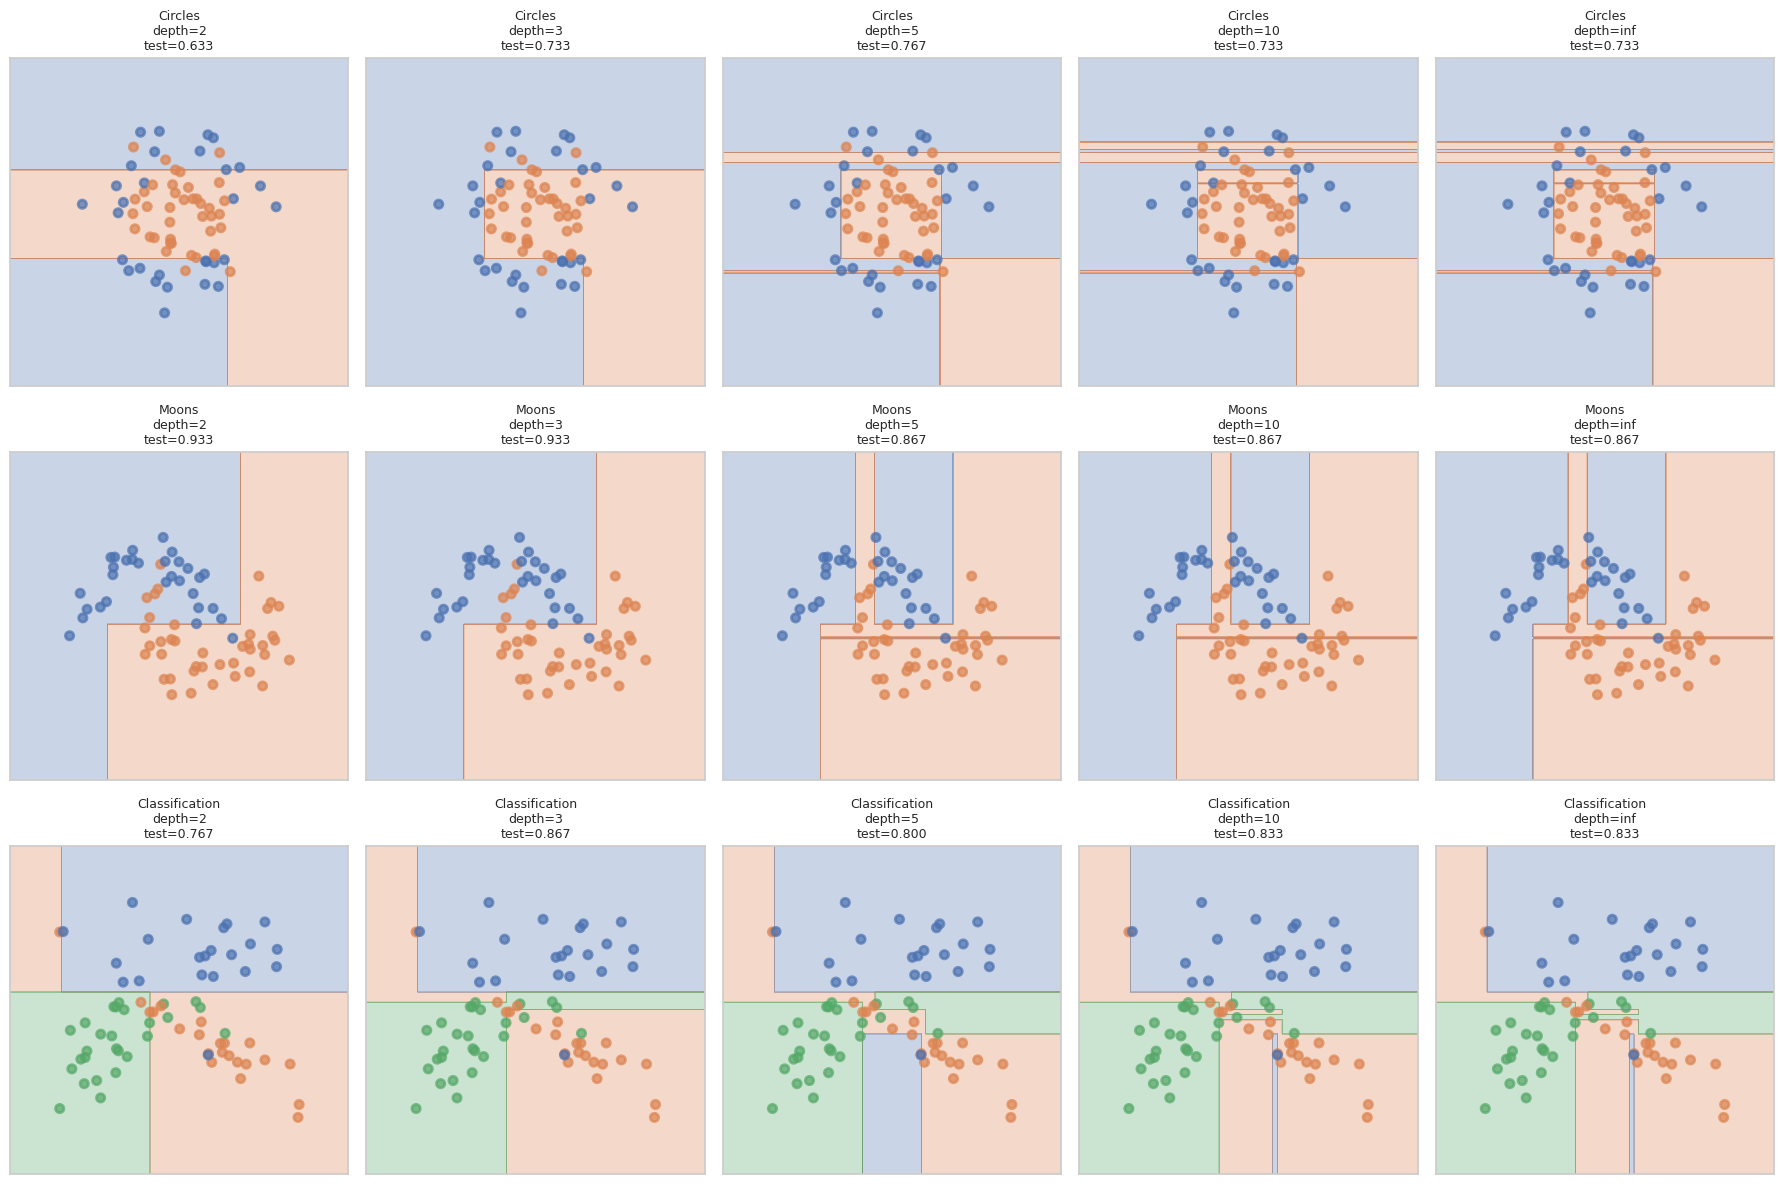


Анализ влияния max_depth:


Circles:
  depth=        2 | train=0.8286 | test=0.6333 | gap=0.1952
  depth=        3 | train=0.8857 | test=0.7333 | gap=0.1524
  depth=        5 | train=0.9714 | test=0.7667 | gap=0.2048
  depth=       10 | train=1.0000 | test=0.7333 | gap=0.2667
  depth=unlimited | train=1.0000 | test=0.7333 | gap=0.2667

Moons:
  depth=        2 | train=0.9143 | test=0.9333 | gap=-0.0190
  depth=        3 | train=0.9143 | test=0.9333 | gap=-0.0190
  depth=        5 | train=1.0000 | test=0.8667 | gap=0.1333
  depth=       10 | train=1.0000 | test=0.8667 | gap=0.1333
  depth=unlimited | train=1.0000 | test=0.8667 | gap=0.1333

Classification:
  depth=        2 | train=0.9000 | test=0.7667 | gap=0.1333
  depth=        3 | train=0.9429 | test=0.8667 | gap=0.0762
  depth=        5 | train=0.9714 | test=0.8000 | gap=0.1714
  depth=       10 | train=1.0000 | test=0.8333 | gap=0.1667
  depth=unlimited | train=1.0000 | test=0.8333 | gap=0.1667


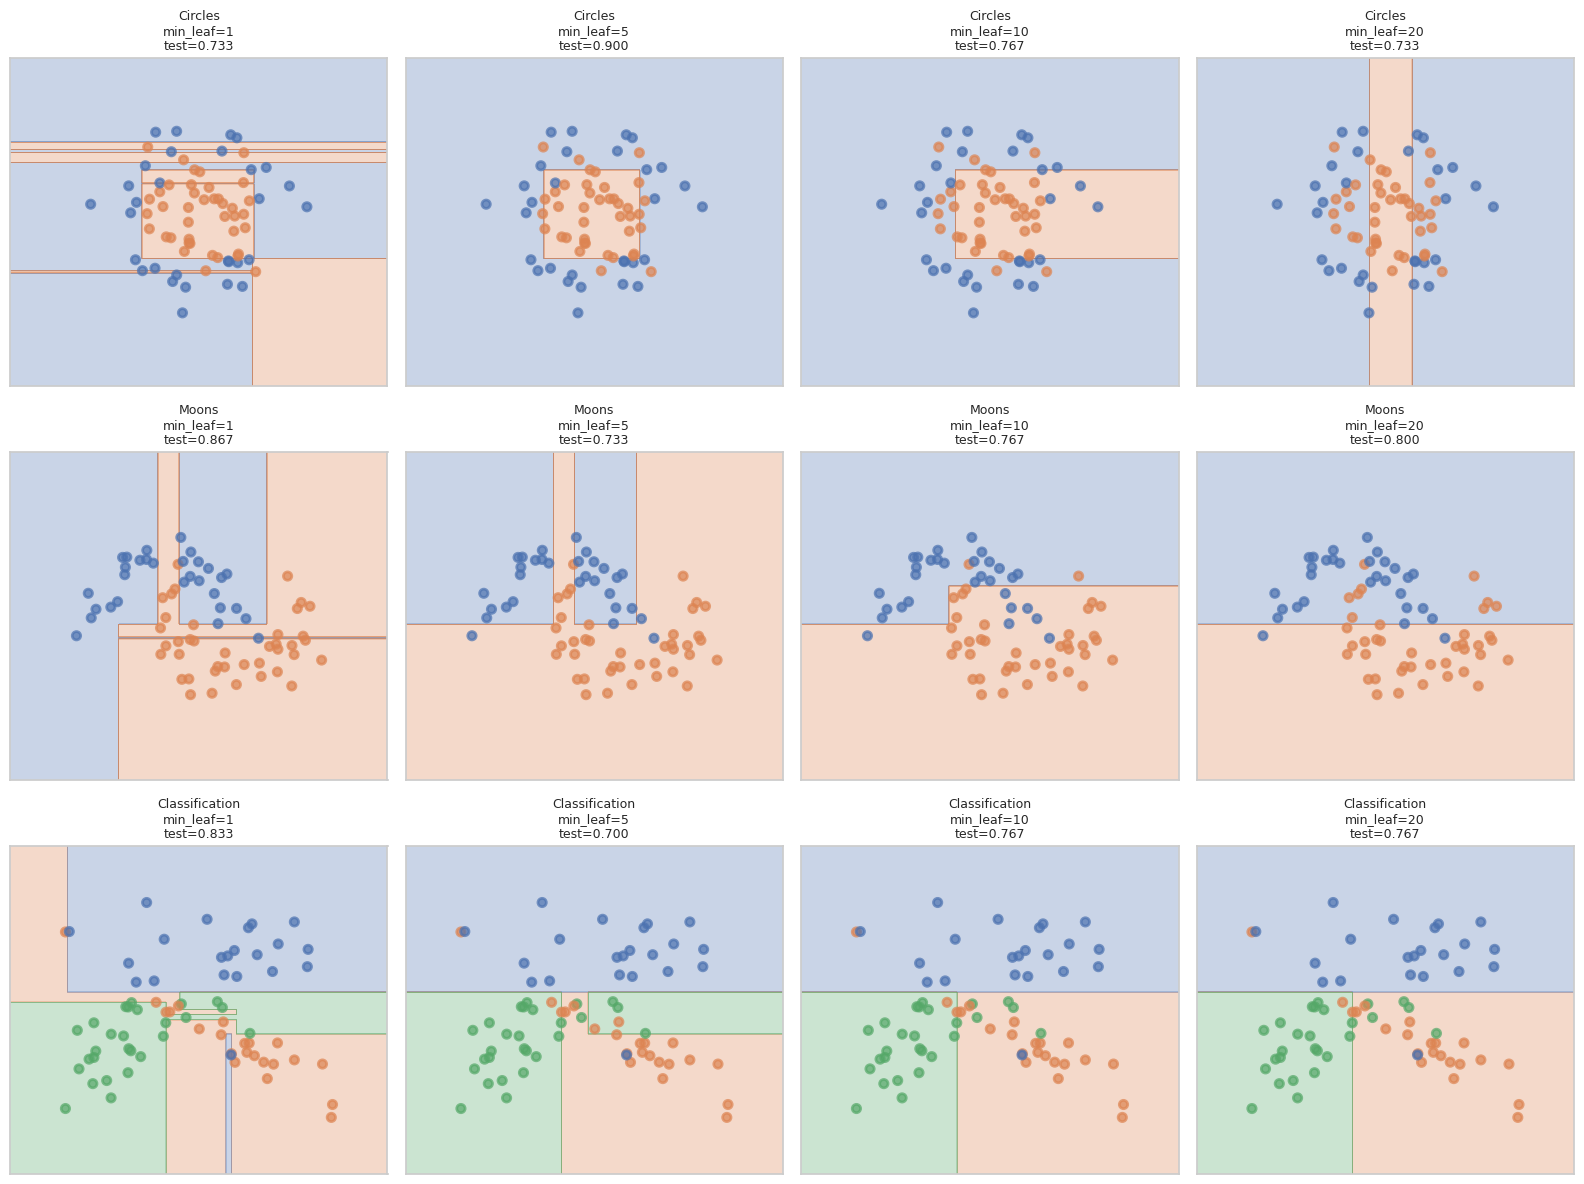


Анализ влияния min_samples_leaf:


Circles:
  min_leaf= 1 | train=1.0000 | test=0.7333 | gap=0.2667
  min_leaf= 5 | train=0.8714 | test=0.9000 | gap=-0.0286
  min_leaf=10 | train=0.8143 | test=0.7667 | gap=0.0476
  min_leaf=20 | train=0.6857 | test=0.7333 | gap=-0.0476

Moons:
  min_leaf= 1 | train=1.0000 | test=0.8667 | gap=0.1333
  min_leaf= 5 | train=0.9571 | test=0.7333 | gap=0.2238
  min_leaf=10 | train=0.8714 | test=0.7667 | gap=0.1048
  min_leaf=20 | train=0.8429 | test=0.8000 | gap=0.0429

Classification:
  min_leaf= 1 | train=1.0000 | test=0.8333 | gap=0.1667
  min_leaf= 5 | train=0.9000 | test=0.7000 | gap=0.2000
  min_leaf=10 | train=0.8857 | test=0.7667 | gap=0.1190
  min_leaf=20 | train=0.8857 | test=0.7667 | gap=0.1190

Подобранные параметры:

Circles: {'max_depth': 4, 'min_samples_leaf': 8} -> train=0.8286, test=0.8000
Moons: {'max_depth': 5, 'min_samples_leaf': 5} -> train=0.9571, test=0.7333
Classification: {'max_depth': 3, 'min_samples_leaf': 10} -> train=0.8857, tes

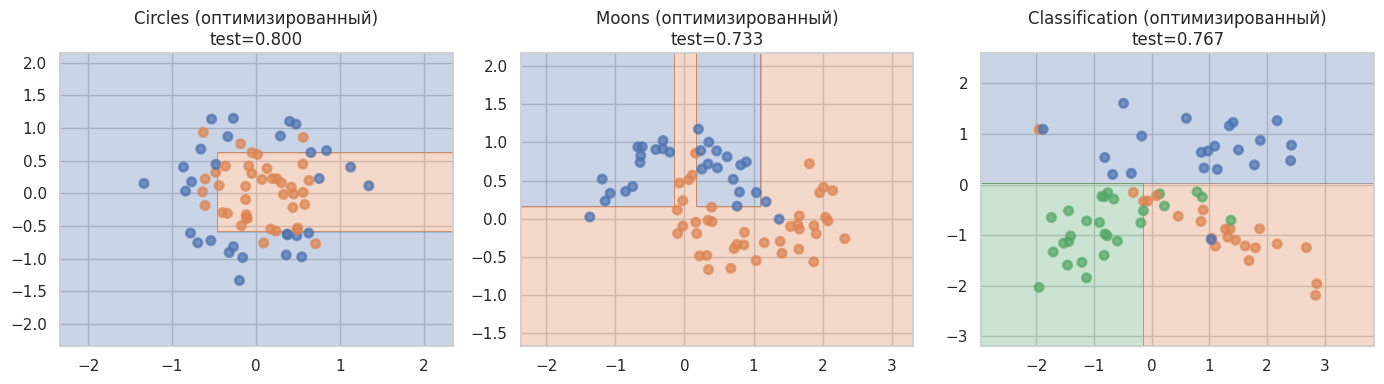

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, 
                       class_sep=0.8, random_state=3, n_redundant=0)
]

dataset_names = ['Circles', 'Moons', 'Classification']

train_sets, test_sets = [], []
for X, y in datasets:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    train_sets.append((X_tr, y_tr))
    test_sets.append((X_te, y_te))

depth_values = [2, 3, 5, 10, None]
leaf_values = [1, 5, 10, 20]

fig1, axes1 = plt.subplots(3, 5, figsize=(18, 12))
depth_metrics = []

for ds_idx, ds_name in enumerate(dataset_names):
    X_tr, y_tr = train_sets[ds_idx]
    X_te, y_te = test_sets[ds_idx]
    
    for depth_idx, depth_val in enumerate(depth_values):
        model = DecisionTreeClassifier(max_depth=depth_val, random_state=42)
        model.fit(X_tr, y_tr)
        
        tr_score = accuracy_score(y_tr, model.predict(X_tr))
        te_score = accuracy_score(y_te, model.predict(X_te))
        
        depth_metrics.append({
            'dataset': ds_name,
            'depth': depth_val if depth_val else 'unlimited',
            'train_acc': tr_score,
            'test_acc': te_score,
            'gap': tr_score - te_score
        })
        
        ax = axes1[ds_idx, depth_idx]
        plt.sca(ax)
        plot_surface(model, X_tr, y_tr)
        depth_label = str(depth_val) if depth_val else 'inf'
        ax.set_title(f'{ds_name}\ndepth={depth_label}\ntest={te_score:.3f}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

print("\nАнализ влияния max_depth:\n")
df_depth = pd.DataFrame(depth_metrics)
for ds in dataset_names:
    print(f"\n{ds}:")
    subset = df_depth[df_depth['dataset'] == ds]
    for _, row in subset.iterrows():
        print(f"  depth={row['depth']:>9} | train={row['train_acc']:.4f} | "
              f"test={row['test_acc']:.4f} | gap={row['gap']:.4f}")

fig2, axes2 = plt.subplots(3, 4, figsize=(16, 12))
leaf_metrics = []

for ds_idx, ds_name in enumerate(dataset_names):
    X_tr, y_tr = train_sets[ds_idx]
    X_te, y_te = test_sets[ds_idx]
    
    for leaf_idx, leaf_val in enumerate(leaf_values):
        model = DecisionTreeClassifier(min_samples_leaf=leaf_val, random_state=42)
        model.fit(X_tr, y_tr)
        
        tr_score = accuracy_score(y_tr, model.predict(X_tr))
        te_score = accuracy_score(y_te, model.predict(X_te))
        
        leaf_metrics.append({
            'dataset': ds_name,
            'min_leaf': leaf_val,
            'train_acc': tr_score,
            'test_acc': te_score,
            'gap': tr_score - te_score
        })
        
        ax = axes2[ds_idx, leaf_idx]
        plt.sca(ax)
        plot_surface(model, X_tr, y_tr)
        ax.set_title(f'{ds_name}\nmin_leaf={leaf_val}\ntest={te_score:.3f}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

print("\nАнализ влияния min_samples_leaf:\n")
df_leaf = pd.DataFrame(leaf_metrics)
for ds in dataset_names:
    print(f"\n{ds}:")
    subset = df_leaf[df_leaf['dataset'] == ds]
    for _, row in subset.iterrows():
        print(f"  min_leaf={row['min_leaf']:>2} | train={row['train_acc']:.4f} | "
              f"test={row['test_acc']:.4f} | gap={row['gap']:.4f}")

best_configs = [
    {'max_depth': 4, 'min_samples_leaf': 8},
    {'max_depth': 5, 'min_samples_leaf': 5},
    {'max_depth': 3, 'min_samples_leaf': 10}
]

fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4))

print("\nПодобранные параметры:\n")
for ds_idx, ds_name in enumerate(dataset_names):
    X_tr, y_tr = train_sets[ds_idx]
    X_te, y_te = test_sets[ds_idx]
    
    tuned_model = DecisionTreeClassifier(**best_configs[ds_idx], random_state=42)
    tuned_model.fit(X_tr, y_tr)
    
    tr_score = accuracy_score(y_tr, tuned_model.predict(X_tr))
    te_score = accuracy_score(y_te, tuned_model.predict(X_te))
    
    print(f"{ds_name}: {best_configs[ds_idx]} -> train={tr_score:.4f}, test={te_score:.4f}")
    
    ax = axes3[ds_idx]
    plt.sca(ax)
    plot_surface(tuned_model, X_tr, y_tr)
    ax.set_title(f'{ds_name} (оптимизированный)\ntest={te_score:.3f}')

plt.tight_layout()
plt.show()


__Ответ:__ Параметры max_depth и min_samples_leaf напрямую влияют на сложность разделяющей поверхности. При увеличении глубины дерево создает более детализированные границы, что улучшает точность на тренировочных данных, но может снижать обобщающую способность. Минимальное число объектов в листе действует как сглаживающий фактор, предотвращая создание узлов под единичные наблюдения. Для датасетов с нелинейными структурами (Circles, Moons) требуется большая гибкость модели, тогда как линейно разделимые данные (Classification) эффективнее обрабатываются при более строгих ограничениях.


# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

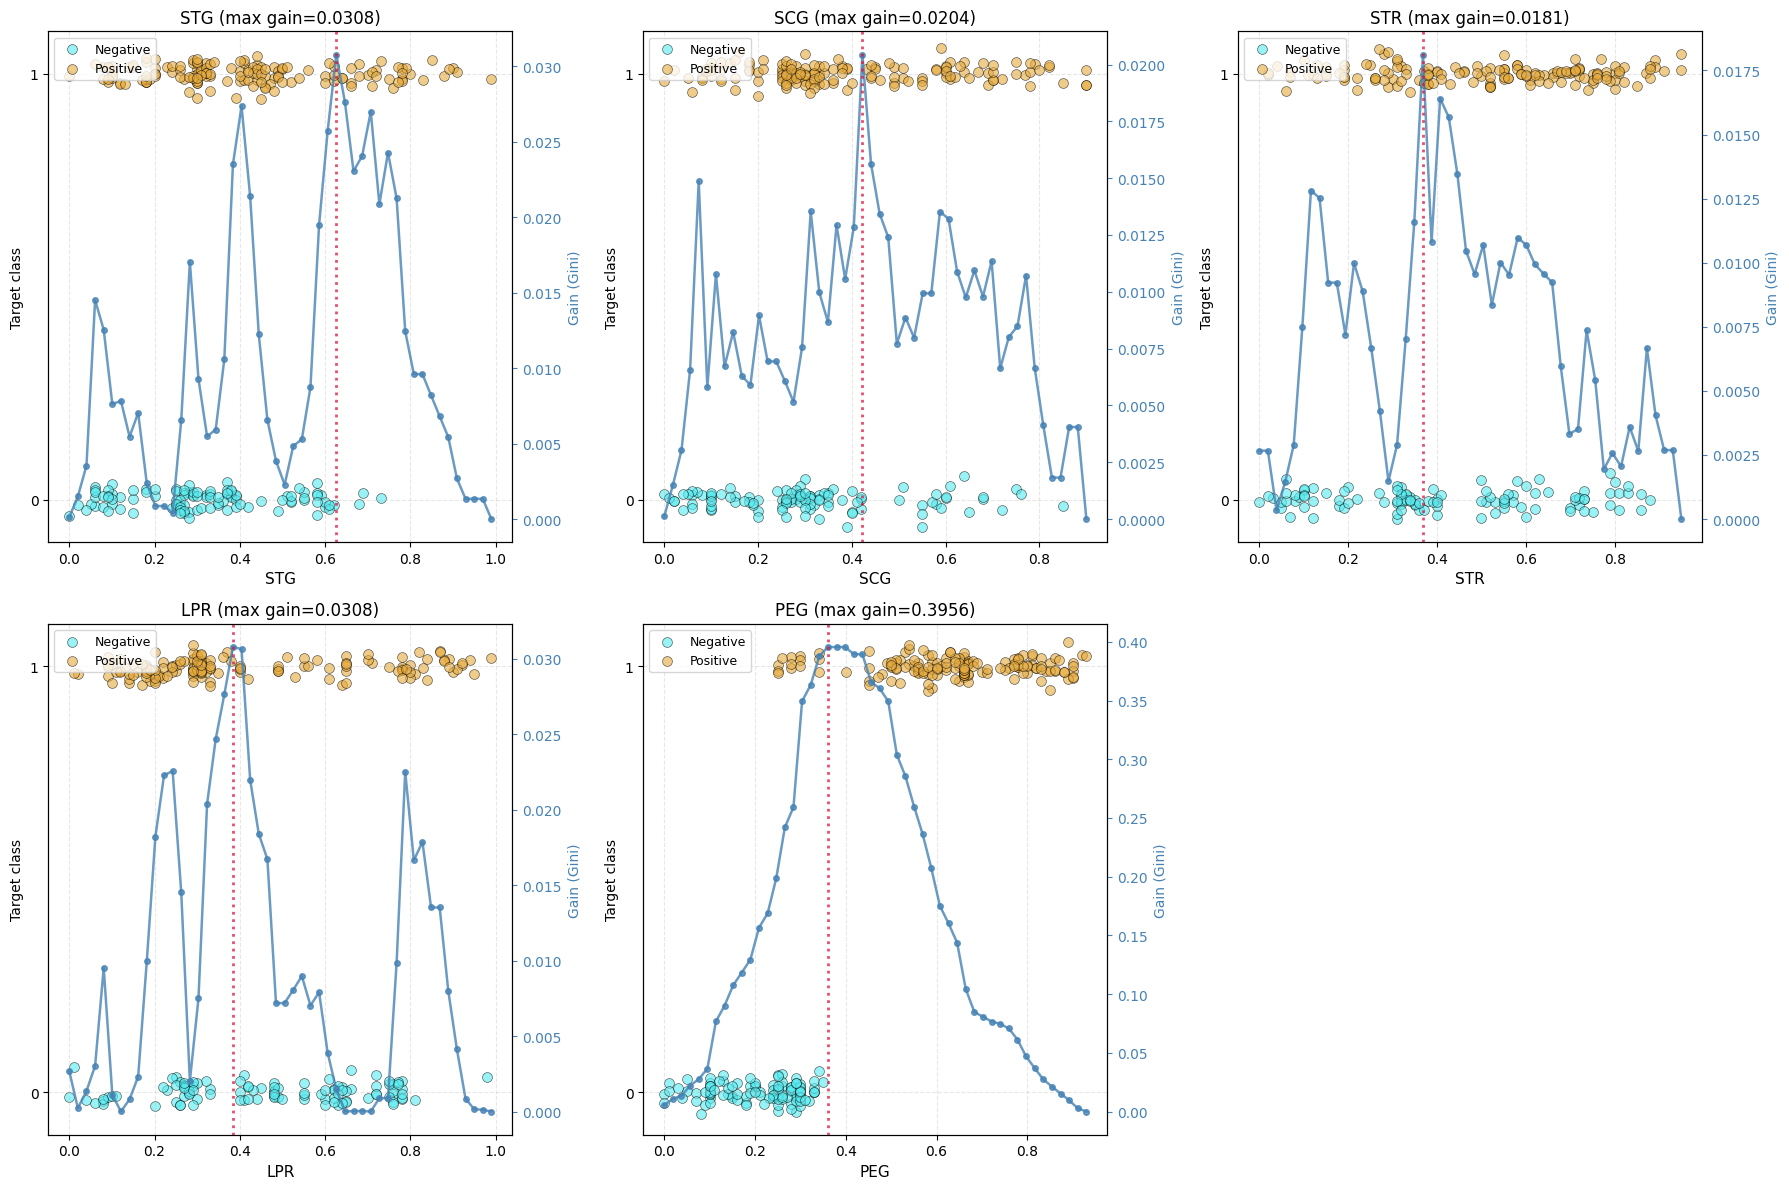

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from hw2code import *

df = pd.read_csv('datasets/students.csv')
features = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

def gini_impurity(labels):
    if len(labels) == 0:
        return 0
    p = np.bincount(labels) / len(labels)
    return 1 - np.sum(p * p)

def find_best_split(feat_col, labels):
    splits = np.linspace(feat_col.min(), feat_col.max(), 50)
    gains = np.zeros(len(splits))
    
    total_imp = gini_impurity(labels)
    for j, split in enumerate(splits):
        left_mask = feat_col <= split
        left_labels = labels[left_mask]
        right_labels = labels[~left_mask]
        
        left_imp = gini_impurity(left_labels) if len(left_labels) > 0 else 0
        right_imp = gini_impurity(right_labels) if len(right_labels) > 0 else 0
        
        gains[j] = total_imp - (len(left_labels)/len(labels)) * left_imp - \
                   (len(right_labels)/len(labels)) * right_imp
    
    opt_idx = np.argmax(gains)
    opt_split, opt_gain = splits[opt_idx], gains[opt_idx]
    
    return splits, gains, opt_split, opt_gain

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ["#56ebf0", "#e7ab3c"]

for idx in range(5):
    ax = axes[idx]
    feat_col = features[:, idx]
    col = df.iloc[:, :-1].columns[idx]
    
    mask_0, mask_1 = labels == 0, labels == 1
    vals_0, vals_1 = feat_col[mask_0], feat_col[mask_1]
    
    jitter_0 = np.random.normal(0, 0.02, len(vals_0))
    jitter_1 = np.random.normal(1, 0.02, len(vals_1))
    
    ax.scatter(vals_0, jitter_0, c=colors[0], alpha=0.6, s=50, 
               label='Negative', edgecolors='k', linewidth=0.5)
    ax.scatter(vals_1, jitter_1, c=colors[1], alpha=0.6, s=50, 
               label='Positive', edgecolors='k', linewidth=0.5)
    
    splits, gains, opt_split, opt_gain = find_best_split(feat_col, labels)
    if opt_gain > 0:
        ax_twin = ax.twinx()
        ax_twin.plot(splits, gains, 'steelblue', linewidth=1.8, 
                    marker='o', markersize=4, alpha=0.8)
        ax_twin.axvline(opt_split, color='crimson', linestyle=':', 
                       linewidth=2, alpha=0.75, label=f'Opt={opt_split:.2f}')
        ax_twin.set_ylabel('Gain (Gini)', fontsize=10, color='steelblue')
        ax_twin.tick_params(colors='steelblue')
    
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Target class', fontsize=10)
    ax.set_title(f'{col} (max gain={opt_gain:.4f})', fontsize=12)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'])
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='both', linestyle='--', alpha=0.3)
    ax.set_ylim(-0.1, 1.1)

axes[-1].axis('off')
fig.tight_layout()
plt.show()


__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**  PEG демонстрирует наибольший прирост по критерию Джини (0.399), что определяет его как оптимальный выбор для корневого узла дерева. Scatter-график подтверждает эффективность разделения: значения ниже порога 0.335 преимущественно соответствуют классу 0, выше — классу 1, образуя выраженную границу между категориями.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from hw2code import DecisionTree
from collections import Counter

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
data = pd.read_csv(url, header=None)

data.columns = ['class', 'cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor',
                'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 
                'stalk_shape', 'stalk_root', 'stalk_surface_above_ring', 
                'stalk_surface_below_ring', 'stalk_color_above_ring', 
                'stalk_color_below_ring', 'veil_type', 'veil_color', 
                'ring_number', 'ring_type', 'spore_print_color', 
                'population', 'habitat']

label_encoders = {}
for col in data.columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

X = data.drop('class', axis=1).values
y = data['class'].values

np.random.seed(666)
indices = np.random.permutation(len(X))
split_idx = len(X) // 2

X_train = X[indices[:split_idx]]
y_train = y[indices[:split_idx]]
X_test = X[indices[split_idx:]]
y_test = y[indices[split_idx:]]

feature_types = ['categorical'] * X.shape[1]

tree = DecisionTree(feature_types, max_depth=10, min_samples_split=2, min_samples_leaf=1)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

def get_depth(node, depth=0):
    if node["type"] == "terminal":
        return depth
    return max(get_depth(node["left_child"], depth + 1), 
               get_depth(node["right_child"], depth + 1))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Depth: {get_depth(tree._tree)}")


Accuracy: 1.0000
Depth: 8


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [12]:
from hw2code import DecisionTree
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import urllib.request
import io

urls = {
    'mushrooms': 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data',
    'tic-tac-toe': 'https://archive.ics.uci.edu/ml/machine-learning-databases/tic-tac-toe/tic-tac-toe.data',
    'cars': 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data',
    'nursery': 'https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data'
}

datasets = {}
for name, url in urls.items():
    with urllib.request.urlopen(url) as response:
        data = pd.read_csv(io.BytesIO(response.read()), header=None)
        datasets[name] = data

def process_target(df, dataset_name):
    if dataset_name == 'mushrooms':
        y = (df.iloc[:, 0] == 'p').astype(int)  
        X = df.iloc[:, 1:]
    elif dataset_name == 'tic-tac-toe':
        y = (df.iloc[:, -1] == 'positive').astype(int) 
        X = df.iloc[:, :-1]
    elif dataset_name == 'cars':
        y_map = {'unacc': 0, 'acc': 0, 'good': 1, 'vgood': 1}
        y = df.iloc[:, -1].map(y_map).astype(int)
        X = df.iloc[:, :-1]
    elif dataset_name == 'nursery':
        y_map = {'not_recom': 0, 'recommend': 0, 'very_recom': 1, 'priority': 1, 'spec_prior': 1}
        y = df.iloc[:, -1].map(y_map).astype(int)
        X = df.iloc[:, :-1]
    return X, y

processed_datasets = {}
for name, df in datasets.items():
    X, y = process_target(df, name)
    processed_datasets[name] = (X, y)

label_encoders = {}
X_label_encoded = {}
for name, (X, y) in processed_datasets.items():
    le_dict = {}
    X_le = X.copy()
    for col in X.columns:
        le = LabelEncoder()
        X_le[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le
    label_encoders[name] = le_dict
    X_label_encoded[name] = X_le
    processed_datasets[name] = (X_le, y.values)  

def create_dt(feature_types):
    class WrappedDT(DecisionTree):
        def __init__(self, feature_types):
            super().__init__(feature_types)
        
        def fit(self, X, y):
            super().fit(X.values if hasattr(X, 'values') else X, y)
            return self
        
        def predict(self, X):
            return super().predict(X.values if hasattr(X, 'values') else X)
    
    return WrappedDT(feature_types)

data_variants = {}
for name in processed_datasets.keys():
    X_le, y = processed_datasets[name]
    
    n_features = X_le.shape[1]
    data_variants[name] = {
        'real': (X_le.values, y, ['real'] * n_features),
        'cat': (X_le.values, y, ['categorical'] * n_features)
    }
    
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_ohe = ohe.fit_transform(X_le)
    data_variants[name]['ohe'] = (X_ohe, y, ['real'] * X_ohe.shape[1])

def custom_cv_score(X, y, feature_types, cv=10, random_state=666):
    model = create_dt(feature_types)
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        scores.append(accuracy_score(y_val, preds))
    
    return np.mean(scores)

results = []
scorer = make_scorer(accuracy_score)

for name in data_variants.keys():
    row = {'dataset': name}
    
    X, y, ftypes = data_variants[name]['real']
    row['DT_real'] = custom_cv_score(X, y, ftypes)
    
    X, y, ftypes = data_variants[name]['cat']
    row['DT_cat'] = custom_cv_score(X, y, ftypes)
    
    X, y, ftypes = data_variants[name]['ohe']
    row['DT_ohe'] = custom_cv_score(X, y, ftypes)
    
    X_le = X_label_encoded[name]
    sklearn_model = DecisionTreeClassifier(random_state=666)
    row['sklearn'] = cross_val_score(sklearn_model, X_le, processed_datasets[name][1], 
                                   cv=10, scoring=scorer).mean()
    
    results.append(row)

df_results = pd.DataFrame(results)
df_results


,dataset,DT_real,DT_cat,DT_ohe,sklearn
0,mushrooms,1.000000,1.000000,1.000000,0.956689
1,tic-tac-toe,0.890329,0.940559,0.940559,0.762346
2,cars,0.991313,0.991313,0.988419,0.943285
3,nursery,0.999691,0.999691,0.999691,0.999691


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:** Алгоритмы ранжируются почти одинаково на всех наборах данных: везде дерево, реализованное в DecisionTree (и с признаками как вещественными, и как категориальными, и с one-hot), показывает очень высокую точность, тогда как DecisionTreeClassifier из sklearn немного уступает по всем датасетам. Это связано с тем, что все признаки здесь категориальные, имеют довольно «чистую» структуру и хорошо отделимы деревом, поэтому разные варианты кодирования (label encoding, категориальное разбиение, one-hot) дают схожий результат, а различия между реализациями деревьев невелики. Компонента случайности есть из‑за случайных разбиений в кросс‑валидации, но на неё можно повлиять: фиксировать random_state, использовать стратифицированную кросс‑валидацию и дополнительно подбирать гиперпараметры глубины и минимального числа объектов в узлах, чтобы немного улучшить и стабилизировать качество.

Вставьте что угодно, описывающее ваши впечатления от этого задания:

In [14]:
hell_yeah = """
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░█░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░███░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░█████░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░███████░░░░░░░░░░░░░░░░░░░
░████░░░░░░░░░░░░░░███████░░░░░░░░░░░░░░████░
░█████░░░░░░░░░░░░█████████░░░░░░░░░░░░█████░
░█████████░░░░░░░░█████████░░░░░░░░█████████░
░░██████████░░░░░███████████░░░░░██████████░░
░░████████████░░░███████████░░░████████████░░
░░░████████████░░███████████░░████████████░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░█████████████████████████████████████░░░░
░░░░░███████████████████████████████████░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░█████████████████████████████░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░████████░████░███████░░░░░░░░░░░░
░░░░░░░░░░░░░░░░█████░██░████░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░██░██░░░░░██░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░██░░░░░░░░██░░░░░░░░░░░░░░░░░░
░░░░░░███░░░█████░██░░█████░░███░░░████░░░░░░
░░░░░█░░██░██░░██░██░██░░██░█░░██░██░░██░░░░░
░░░░░░████░██░░██░██░██░░██░░████░████░░░░░░░
░░░░░██░██░██░░██░██░██░░██░██░██░░░████░░░░░
░░░░░██░██░██░░██░██░██░░██░██░██░██░░██░░░░░
░░░░░░████░░█████░██░░█████░░████░░████░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
"""
print(hell_yeah)


░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░█░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░███░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░█████░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░███████░░░░░░░░░░░░░░░░░░░
░████░░░░░░░░░░░░░░███████░░░░░░░░░░░░░░████░
░█████░░░░░░░░░░░░█████████░░░░░░░░░░░░█████░
░█████████░░░░░░░░█████████░░░░░░░░█████████░
░░██████████░░░░░███████████░░░░░██████████░░
░░████████████░░░███████████░░░████████████░░
░░░████████████░░███████████░░████████████░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░█████████████████████████████████████░░░░
░░░░░███████████████████████████████████░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░█████████████████████████████░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░████████░████░███████░░░░░░░░░░░░
░░░░░░░░░░░░░░░░█████░██░████░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
░░░░░░░░░░░░░░░██░██░░░░░██░░░░░░